# Thematic Search with Unsupervised Topic Modeling

In this page, we will create a TopicDatabase of the [United Nations General Debate Corpus](https://www.kaggle.com/datasets/unitednations/un-general-debates) so we can do Thematic Search. 

This corpus does not come with any topic metadata, so our first step is to generate a topic hierarchy and assign topic strengths to each document in the dataset. To do this, we will be using a typical unsupervised topic modeling pipeline: vectorize the documents, dimension reduce, cluster, and then represent the clusters with topic metadata.

## Setting up the Topic Database

The first steps in the topic modeling pipeline is to chunk our documents and embed the chunks. As this is standard practice, we're going to grab a copy of the dataset from HuggingFace that has pre-computed chunks, embedding vectors and UMAP reduced vectors. The dataset as well as more details on its creation [is available here](https://huggingface.co/datasets/kalebr/un-general-debate-corpus-chunked).

In [10]:
import pandas as pd
import numpy as np

ungdc_df = pd.read_parquet("https://huggingface.co/datasets/kalebr/un-general-debate-corpus-chunked/resolve/main/ungdc-all-chunked.parquet")


embedding_vectors = np.stack(ungdc_df['embedding'].values)
reduced_vectors = np.stack(ungdc_df['reduced'].values)
text = ungdc_df['chunk_text'].to_numpy()

ungdc_df.head(1)

,original_index,chunk_text,token_count,embedding,reduced,session,year,country,information_weight
0,0,﻿It is indeed a pleasure for me and the member...,107,"[0.0061351038, 0.020647585, 0.01789057, 0.0222...","[6.317007541656494, 7.351022243499756]",44,1989,MDV,39.726044


### Computing a Topic Hierarchy

Next, we will use Toponymy to generate a topic hierarchy and assign topic labels to the chunks in our dataset. Toponymy first uses HDBSCAN to generate a set of cluster layers that are organized into a tree, and assigns each vector a cluster label for each layer of the hierarchy (possibly -1 for noise). Then it uses an LLM to generate topic names for each cluster by passing it context about the cluster, such as keyphrases and example snippets.

First we need to initialize our LLM wrapper - I am using Claude 3 Haiku - and then we need to set up our Toponymy parameters.

In [11]:
## Toponymy LLM Wrapper Setup
from toponymy.llm_wrappers import AnthropicNamer

llm = AnthropicNamer(
    api_key="your-api-key-here",
    model="claude-3-haiku-20240307",  # Fast and cost-effective
    llm_specific_instructions="Generate coherent, descriptive names"
)

## Toponymy settings
model_name = 'all-MiniLM-L6-v2' # embedding model.

toponymy_object_description = "excerpts from a speech"
toponymy_corpus_description = "United Nations General Debate Transcripts"

toponymy_exemplar_method = "central"
toponymy_keyphrase_method = "information_weighted"
toponymy_subtopic_method = "facility_location"

clusterer_params = {
    'min_clusters':4,
    'base_min_cluster_size':25,
    'verbose':True
}

Next, we can run Toponymy. Since I've already run it myself, I am going to load the serialized output instead:

In [ ]:
from toponymy.serialization import TopicModel
from sentence_transformers import SentenceTransformer
import torch

if False:
    from toponymy import Toponymy, ToponymyClusterer

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    model = SentenceTransformer(model_name, device=device)
    print(f"Loaded model: {model_name}")

    clusterer = ToponymyClusterer(**clusterer_params)
    clusterer.fit(reduced_vectors, embedding_vectors)
    toponymy_params = {
        'llm_wrapper':llm,
        'text_embedding_model':model,
        'clusterer':clusterer,
        'object_description':"excerpts from a speech",
        'corpus_description':"United Nations General Debate Transcripts",
        'exemplar_delimiters':["<EXAMPLE_TRANSCRIPT>\n","\n</EXAMPLE_TRANSCRIPT>\n\n"],
    }
    toponymy_fit_params = {
        'exemplar_method':toponymy_exemplar_method,
        'keyphrase_method':toponymy_keyphrase_method,
        'subtopic_method':toponymy_subtopic_method,
    }

    toponymy = Toponymy(**toponymy_params)
    toponymy.fit(text, embedding_vectors, reduced_vectors, **toponymy_fit_params)

    topicmodel = TopicModel.from_toponymy(toponymy, document_df=df)

if True:
    from pathlib import Path

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if not Path('ungdc-full-topic-model.tm.zip').is_file():
        !curl -O https://huggingface.co/datasets/kalebr/un-general-debate-corpus-chunked/resolve/main/ungdc-full-topic-model.tm.zip
    
    model = SentenceTransformer("all-mpnet-base-v2", device=device)
    print(f"Loaded model: all-mpnet-base-v2")

    topicmodel = TopicModel.from_file('ungdc-full-topic-model.tm.zip')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: all-mpnet-base-v2


Toponymy's `TopicModel` class contains the following data from Toponymy:
- The cluster_tree `topicmodel.cluster_tree`
- The topic representation metadata `topicmodel.topic_df`
- The embedding vectors `topicmodel.embedding_vectors`
- The reduced vectors `topicmodel.reduced_vectors`
- The cluster inclusion matrices `topicmodel.cluster_layers`

Conveniently, the TopicModel contains everything you need to build a TopicDatabase. For example, here is the topic metadata:

In [33]:
topicmodel.topic_df

,uid,layer,cluster,name,keyphrases
0,AAAB,0,0,Conflict and political reconciliation in North...,"[people of northern ireland, british and irish..."
1,AAAC,0,1,Antarctica's status as the common heritage of ...,"[question of antarctica, antarctic treaty, con..."
2,AAAD,0,2,Implementation of South Tyrol Autonomy Agreeme...,"[autonomy of south tyrol, austria and italy, r..."
3,AAAE,0,3,Decolonization and self-determination of New C...,"[people of new caledonia, south pacific forum,..."
4,AAAF,0,4,Decolonization and self-determination of East ...,"[people of east timor, leadership of fretilin,..."
...,...,...,...,...,...
613,AAwE,3,3,Latin American Integration and Conflicts,"[central american countries, government of gua..."
614,AAwF,3,4,Congratulations and Tributes to UN Leadership,"[election to the presidency, mr president, sir..."
615,AAwG,3,5,Nuclear Disarmament and European Security,"[non-proliferation of nuclear weapons, nuclear..."
616,AAwH,3,6,UN Reform and Global Order,"[disarmament, nuclear weapons, developing coun..."


### Propagating Labels to Noise Points

Although we could make a TopicDatabase with what we have now, I want to first assign topic strengths to all the noise points by using scikit-learn's `LabelSpreading` algorithm to predict soft inclusion strengths for each topic to each noise point, using the Topoynymy labels as training data.

In [34]:
from sklearn.semi_supervised import LabelSpreading

spreader = LabelSpreading(kernel='knn')

soft_layers = []
for matrix in topicmodel.cluster_layers:
    labels = np.asarray(np.argmax(matrix,axis=1))
    spreader.fit(topicmodel.embedding_vectors, labels.flatten())
    soft_layers.append(spreader.label_distributions_)


### Initializing the Topic Database

Now we have everything we need to initialize the topic database:

In [46]:
from thematic_search import TopicDatabase, SoftClusterTree

topicdb = TopicDatabase(
    soft_cluster_tree=SoftClusterTree(
        soft_layers,
        topicmodel.cluster_tree,
    ),
    embedding_vectors=topicmodel.embedding_vectors,
    reduced_vectors=topicmodel.reduced_vectors,
    document_df=ungdc_df.drop(columns=['embedding', 'reduced']),
    topic_df=topicmodel.topic_df,
    embedding_model=model
)
topicdb

## Searching and Visualizing

Now with our chunk database and speech database both ready to go, lets go through some example usage.

First, lets query for high-level (layer>=3) topics in the speeches given by the Canadian delegation, with strength at least 0.75:

In [50]:
topicdb.q.docs_where("country=='CAN'").topics(0.9).where('layer>=3').info()

,layer,cluster,name,keyphrases
uid,,,,
AAwB,3,0,Southeast Asian Geopolitics,"[government of democratic kampuchea, vietnames..."
AAwC,3,1,Middle East Conflicts,"[palestinian people, israel, occupied arab ter..."
AAwD,3,2,Decolonization and Anti-Apartheid,"[people of south africa, south african governm..."
AAwE,3,3,Latin American Integration and Conflicts,"[central american countries, government of gua..."
AAwG,3,5,Nuclear Disarmament and European Security,"[non-proliferation of nuclear weapons, nuclear..."
AAwH,3,6,UN Reform and Global Order,"[disarmament, nuclear weapons, developing coun..."
AAwI,3,7,Reforming Global Economic Order,"[developing countries, terms of trade, new int..."


Next, we will find the 25 nearest neighbours of the embedding of "war between Iran and Iraq", ask for the theme of that set and print it's name.

Then we can take that theme and find all the documents in the theme with strength at least 0.9.

In [52]:
topic = topicdb.q.search("war between Iran and Iraq",k=25).theme().info()

print(f'Theme: {topic.name.values[0]}')

topicdb.q.topic_uid(topic.index.values[0]).inside(0.9).documents().head(3)

Theme: Efforts to end the Iran-Iraq war through mediation and UN resolutions


,original_index,chunk_text,token_count,session,year,country,information_weight
407,24,The Republic of Rwanda expects the forty-fourt...,115,44,1989,RWA,30.218451
12593,1332,67.\tIt is painful to me to see a group of nat...,271,30,1975,ISR,52.863018
23437,3009,But the monetary crisis which at present is of...,122,26,1971,TCD,29.116763


For a bit of visualization, we can look at all the chunks in a topic's interior and boundary. By interior, we mean inclusion strength = 1, and by boundary we mean inclusion strength in (0,1).

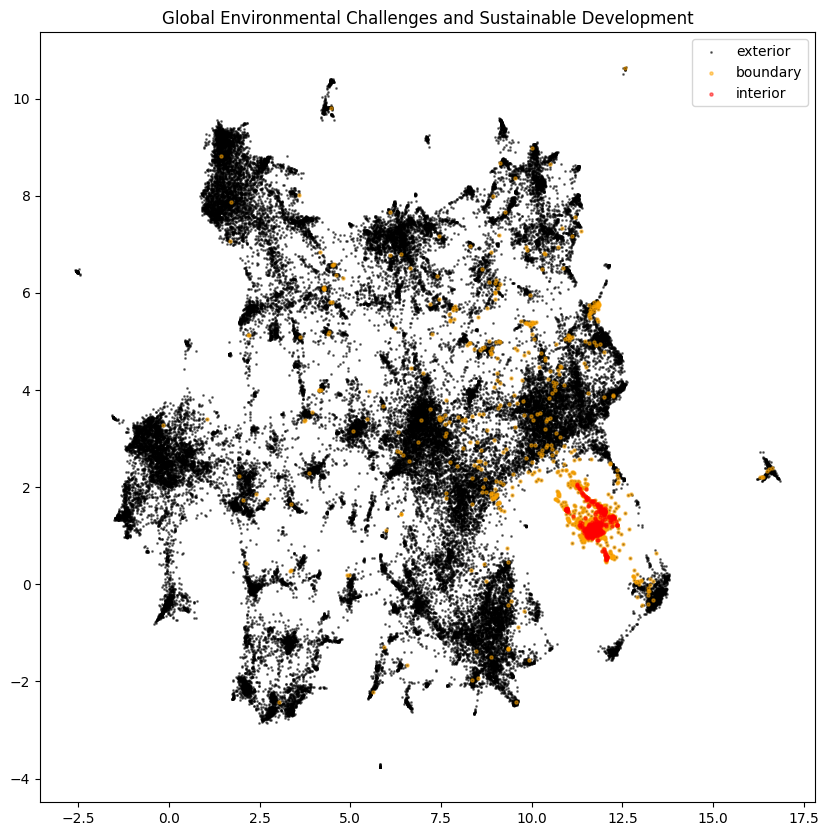

In [ ]:
import matplotlib.pyplot as plt

topic = (2,8)

topic_info = topicdb.q.topic(*topic).info()

bdry_index = topicdb.q.topic(*topic).inside(0.01).indices
intr_index = topicdb.q.topic(*topic).inside().indices

fig,ax=plt.subplots(figsize=(10,10))
plt.title(topic_info.name.values[0])
plt.scatter(
    topicdb.reduced_vectors[:,0], topicdb.reduced_vectors[:,1],
    s=1, c='k', alpha=0.5, label='exterior'
)
plt.scatter(
    topicdb.reduced_vectors[bdry_index,0], topicdb.reduced_vectors[bdry_index,1],
    s=5, c='orange', alpha=0.5, label='boundary'
)
plt.scatter(
    topicdb.reduced_vectors[intr_index,0], topicdb.reduced_vectors[intr_index,1],
    s=5, c='red', alpha=0.5, label='interior'
)
plt.legend()
plt.show()

